# Image Processing SoSe 2026 - Assignment - 03

### Deadline is 07.05.2026 at 11:55 a.m.

#### Students: Fabio Julius

Please solve the assignments together with a partner.

Make sure the code runs without errors, when clicking `Kernel` -> `Restart Kernel & Run All Cells`. Then save the notebook and upload your submission.

In [119]:
from numpy.ma.core import arctan
# display the plots inside the notebook
%matplotlib inline

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import pylab
from skimage.data import cat, coins
from skimage.color import rgb2gray, rgb2hsv, hsv2rgb

pylab.rcParams['figure.figsize'] = (12, 12)   # This makes the plot bigger

# Exercise 1 - 5 Points

Implement affine transformation with [linear interpolation].
Implement the functions `affine_transformation` and `bilinear_interpolation`. Apply some affine transformation of your choice and smooth the output using your bilinear interpolation.


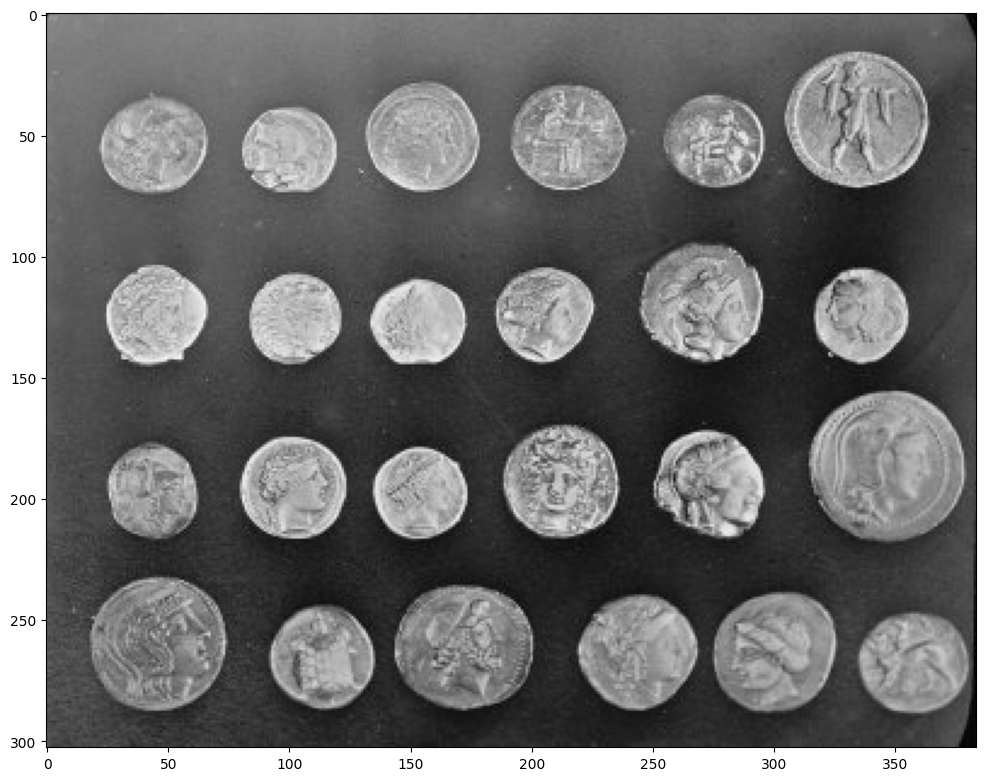

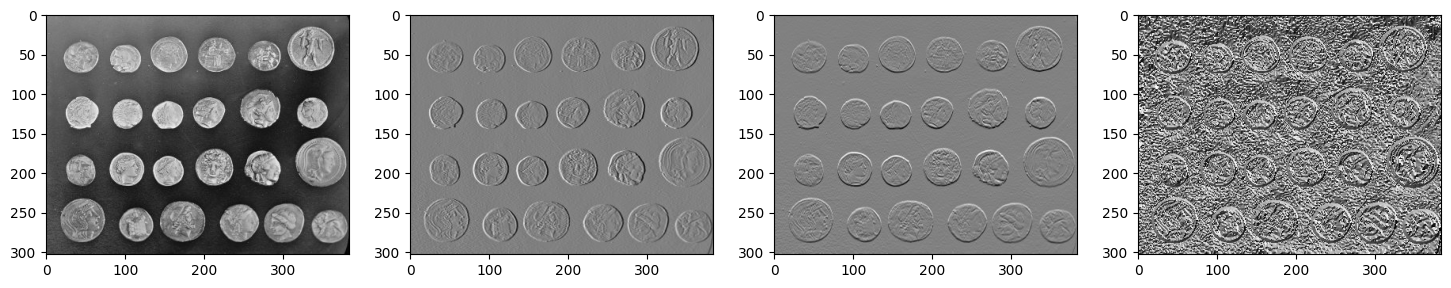

In [121]:
# We use a gray image. All the algorithms should work with color images too.
img = coins() / 255.
plt.imshow(img, cmap='gray', vmin=0, vmax=1)
plt.show()

def derive_y(image):
    """Computes the derivative of the image w.r.t the y coordinate"""
    _, dy = np.gradient(image, axis=(1, 0))
    return dy

def derive_x(image):
    """Computes the derivative of the image w.r.t the x coordinate"""
    dx, _ = np.gradient(image, axis=(1, 0))
    return dx

dx_img = derive_x(img)
dy_img = derive_y(img)
atan_img = np.atan2(dy_img, dx_img)
plt.figure(figsize=(18, 12))
plt.subplot(141)
plt.imshow(img, cmap='gray', vmin=0, vmax=1)
plt.subplot(142)
plt.imshow(dx_img, cmap='gray')
plt.subplot(143)
plt.imshow(dy_img, cmap='gray')
plt.subplot(144)
plt.imshow(atan_img, cmap='gray')
plt.show()


Here are some sample affine transformations to be used later on

In [122]:
T_scale = np.array([
    [0.75, 0, 0],
    [0, 0.75, 0],
    [0, 0, 1],
])
T_shear = np.array([
    [1, 0.3, 0],
    [0, 1, 0],
    [0, 0, 1],
])

# you can use this function to invert the matrices
np.linalg.inv(T_scale)

array([[1.33333333, 0.        , 0.        ],
       [0.        , 1.33333333, 0.        ],
       [0.        , 0.        , 1.        ]])

In [123]:
def bilinear_interpolation(img, indices):
    image = np.zeros(indices.shape, dtype=img.dtype)
    
    def interpolate_pixel(x, y):
        x1 = int(np.floor(x))
        x2 = int( np.ceil(x))
        y1 = int(np.floor(y))
        y2 = int( np.ceil(y))

        if x1 < 0 or x2 >= img.shape[1] or y1 < 0 or y2 >= img.shape[0]:
            return 0

        Q11 = img[y1, x1]
        Q12 = img[y1, x2]
        Q21 = img[y2, x1]
        Q22 = img[y2, x2]

        R1 = ((x2 - x) * Q11 + (x - x1) * Q12) / (x2 - x1)
        R2 = ((x2 - x) * Q21 + (x - x1) * Q22) / (x2 - x1)
        P  = ((y2 - y) *  R1 + (y - y1) *  R2) / (y2 - y1)

        R1 = ((x2 - x) * Q11 + (x - x1) * Q12) / (x2 - x1) if Q21 != Q22 else Q11
        R2 = ((x2 - x) * Q21 + (x - x1) * Q22) / (x2 - x1) if Q21 != Q22 else Q21
        P =  ((y2 - y) *  R1 + (y - y1) *  R2) / (y2 - y1) if  R1 !=  R2 else  R1

        return P
    
    for x in range(indices.shape[1]):
        for y in range(indices.shape[0]):
             image[y, x] = interpolate_pixel(indices[y, x][0], indices[y, x][1])

    return image

In [124]:
def affine_transformation(img, matrix):
    indices = np.empty((int(np.floor(img.shape[0] * matrix[0,0])), int(np.ceil(img.shape[1] * matrix[1,1]))), dtype=object)
    inverted_matrix = np.linalg.inv(matrix)

    def get_translate_pixel_cords(x, y):
        pixel_cords = np.array([x, y, 1])
        translate_pixel_cords = np.dot(inverted_matrix, pixel_cords)
        return translate_pixel_cords[:2]
    
    for x in range(indices.shape[1]):
        for y in range(indices.shape[0]):
            indices[y, x] = get_translate_pixel_cords(x, y)
    
    return bilinear_interpolation(img, indices)

C:\Users\Fabio\AppData\Local\Temp\ipykernel_13144\3860820654.py:18: RuntimeWarning: invalid value encountered in scalar divide
  R1 = ((x2 - x) * Q11 + (x - x1) * Q12) / (x2 - x1)
C:\Users\Fabio\AppData\Local\Temp\ipykernel_13144\3860820654.py:19: RuntimeWarning: invalid value encountered in scalar divide
  R2 = ((x2 - x) * Q21 + (x - x1) * Q22) / (x2 - x1)
C:\Users\Fabio\AppData\Local\Temp\ipykernel_13144\3860820654.py:20: RuntimeWarning: invalid value encountered in scalar divide
  P  = ((y2 - y) *  R1 + (y - y1) *  R2) / (y2 - y1)


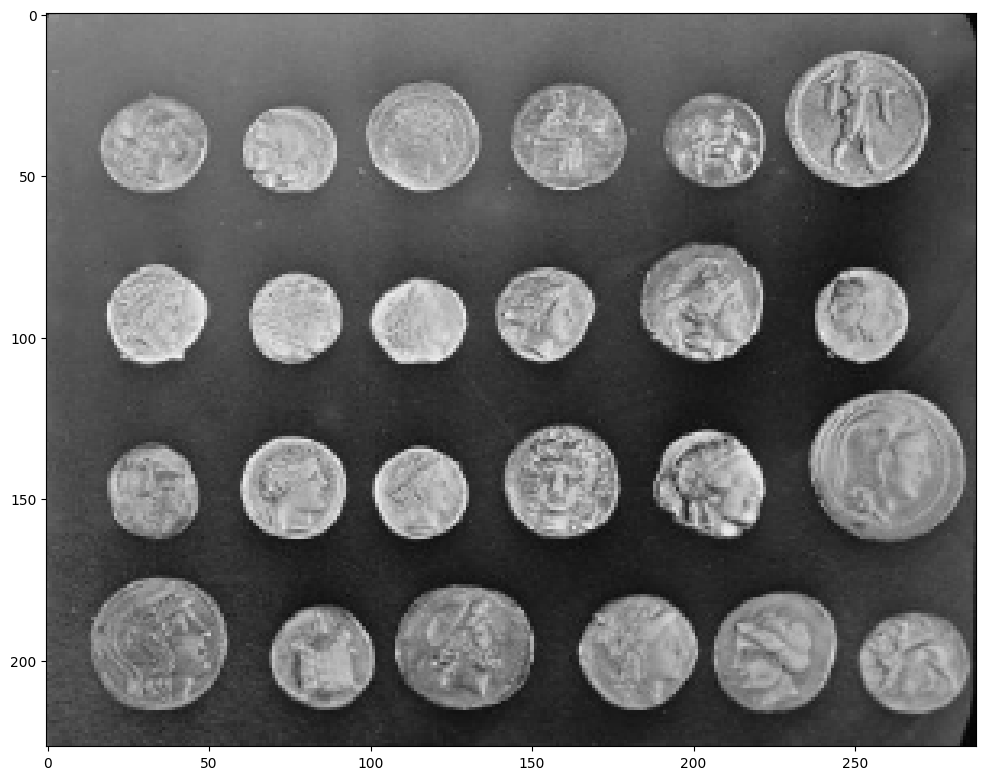

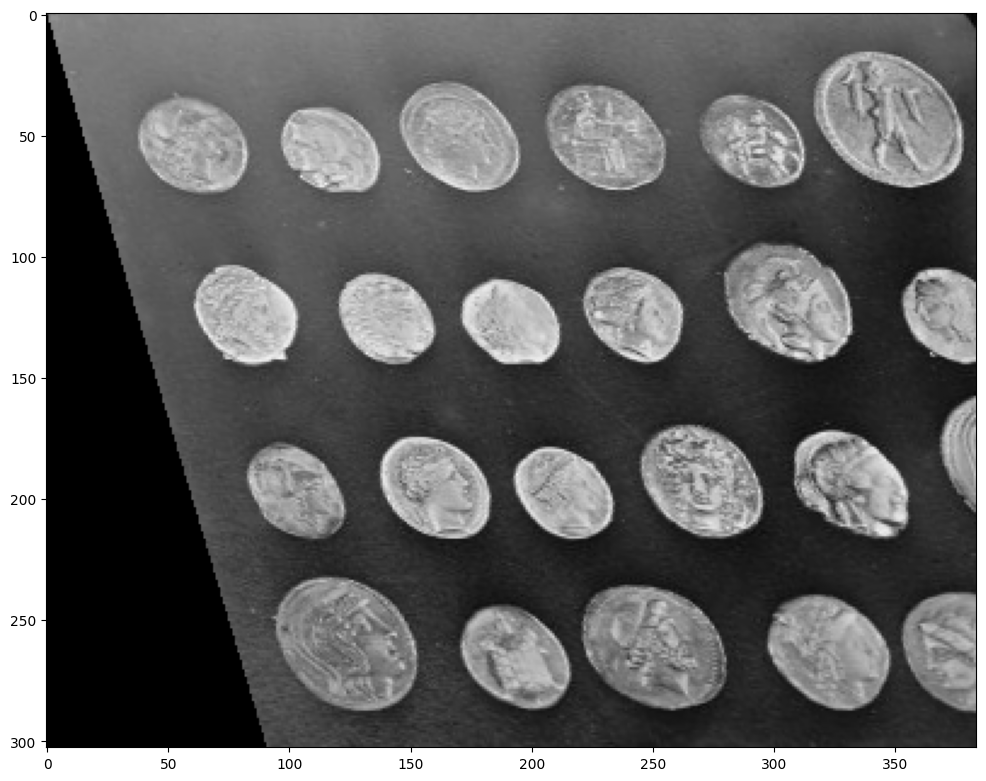

In [125]:
img_scale = affine_transformation(img, T_scale)
img_shear = affine_transformation(img, T_shear)
plt.imshow(img_scale, cmap='gray', vmin=0, vmax=1)
plt.show()
plt.imshow(img_shear, cmap='gray', vmin=0, vmax=1)
plt.show()

# Exercise 2 - Bicubic interpolation - 5 Points

Implement affine transformation with [bicubic interpolation](https://en.wikipedia.org/wiki/Bicubic_interpolation).
Implement the functions `affine_transformation` and `bicubic_interpolation`. Apply some affine transformation of your choice and smooth the output using your bicubic interpolation.

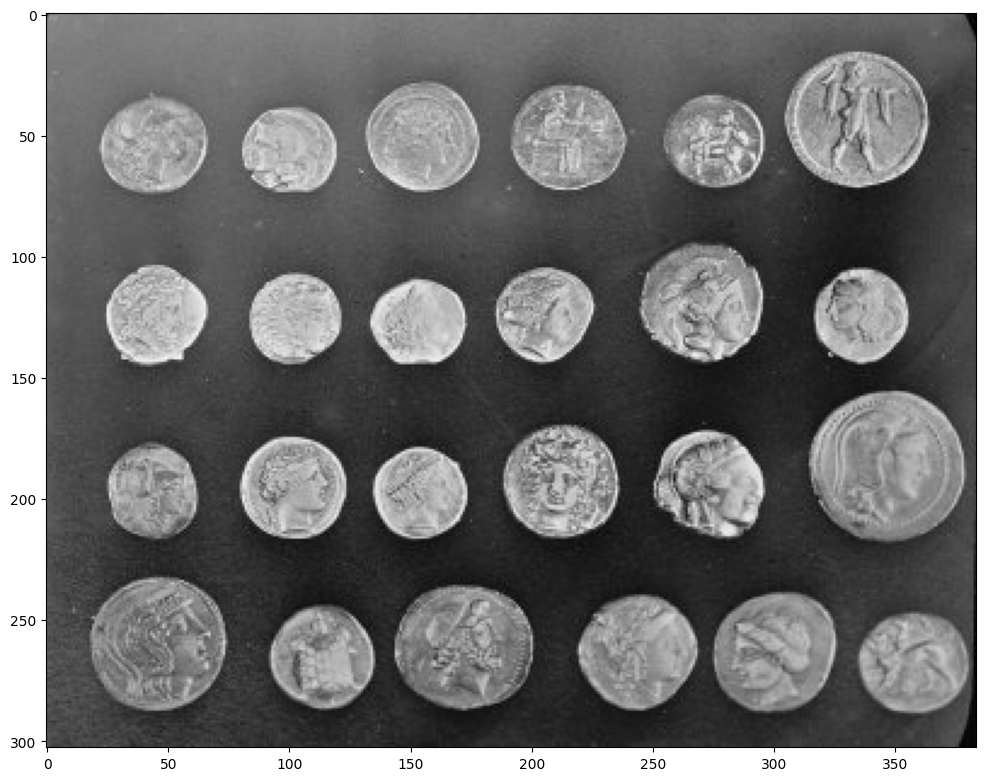

In [126]:
# We use a gray image. All the algorithms should work with color images too.
img = coins() / 255.
plt.imshow(img, cmap='gray', vmin=0, vmax=1)
plt.show()

In [127]:
def derive_y(image):
    """Computes the derivative of the image w.r.t the y coordinate"""
    _, dy = np.gradient(image, axis=(1, 0))
    return dy

def derive_x(image):
    """Computes the derivative of the image w.r.t the x coordinate"""
    dx, _ = np.gradient(image, axis=(1, 0))
    return dx

In [128]:
dx_img = derive_x(img)
dy_img = derive_y(img)

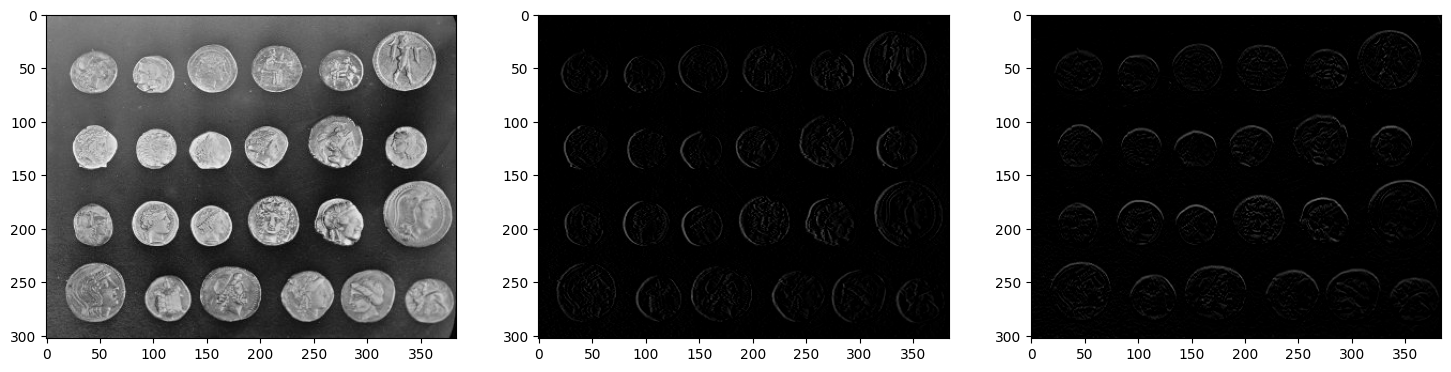

In [129]:
plt.figure(figsize=(18, 12))
plt.subplot(131)
plt.imshow(img, cmap='gray', vmin=0, vmax=1)
plt.subplot(132)
plt.imshow(dx_img, cmap='gray', vmin=0, vmax=1)
plt.subplot(133)
plt.imshow(dy_img, cmap='gray', vmin=0, vmax=1)
plt.show()

Here are some sample affine transformations to be used later on

In [130]:
T_scale = np.array([
    [0.75, 0, 0],
    [0, 0.75, 0],
    [0, 0, 1],
])
T_affine = np.array([
    [1, 0.3, 0],
    [0, 1, 0],
    [0, 0, 1],
])

# you can use this function to invert the matrices
np.linalg.inv(T_scale)

array([[1.33333333, 0.        , 0.        ],
       [0.        , 1.33333333, 0.        ],
       [0.        , 0.        , 1.        ]])

In [131]:
def affine_transformation(img, matrix):
    indices = np.empty((int(np.floor(img.shape[0] * matrix[0,0])), int(np.ceil(img.shape[1] * matrix[1,1]))), dtype=object)
    inverted_matrix = np.linalg.inv(matrix)

    def get_translate_pixel_cords(x, y):
        pixel_cords = np.array([x, y, 1])
        translate_pixel_cords = np.dot(inverted_matrix, pixel_cords)
        return translate_pixel_cords[:2]
    
    for x in range(indices.shape[1]):
        for y in range(indices.shape[0]):
            indices[y, x] = get_translate_pixel_cords(x, y)
    
    return bicubic_interpolation(img, indices)


def bicubic_interpolation(img, indices):
    dx_img = derive_x(img)
    dy_img = derive_y(img)
    dxy_img = derive_x(dy_img)

    A_inv = np.array([
        [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [-3,  3,  0,  0, -2, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 2, -2,  0,  0,  1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],

        [ 0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0, -3,  3,  0,  0, -2, -1,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  2, -2,  0,  0,  1,  1,  0,  0],

        [-3,  0,  3,  0,  0,  0,  0,  0, -2,  0, -1,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0, -3,  0,  3,  0,  0,  0,  0,  0, -2,  0, -1,  0],
        [ 9, -9, -9,  9,  6,  3, -6, -3,  6, -6,  3, -3,  4,  2,  2,  1],
        [-6,  6,  6, -6, -3, -3,  3,  3, -4,  4, -2,  2, -2, -2, -1, -1],

        [ 2,  0, -2,  0,  0,  0,  0,  0,  1,  0,  1,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  2,  0, -2,  0,  0,  0,  0,  0,  1,  0,  1,  0],
        [-6,  6,  6, -6, -4, -2,  4,  2, -3,  3, -3,  3, -2, -1, -2, -1],
        [ 4, -4, -4,  4,  2,  2, -2, -2,  2, -2,  2, -2,  1,  1,  1,  1]
    ], dtype=float)

    image = np.zeros(indices.shape, dtype=img.dtype)

    def interpolate_pixel(x, y):
        h, w = img.shape[:2]
        x0 = int(np.floor(x))
        y0 = int(np.floor(y))
        u = x - x0
        v = y - y0

        def clamp(arr, ix, iy):
            if ix < 0 or ix >= w or iy < 0 or iy >= h:
                return 0
            ix = min(max(ix, 0), w - 1)
            iy = min(max(iy, 0), h - 1)
            return arr[iy, ix]

        b = np.array([
            clamp(img, x0, y0), clamp(img, x0+1, y0), clamp(img, x0, y0+1), clamp(img, x0+1, y0+1),
            clamp(dx_img, x0, y0), clamp(dx_img, x0+1, y0), clamp(dx_img, x0, y0+1), clamp(dx_img, x0+1, y0+1),
            clamp(dy_img, x0, y0), clamp(dy_img, x0+1, y0), clamp(dy_img, x0, y0+1), clamp(dy_img, x0+1, y0+1),
            clamp(dxy_img, x0, y0), clamp(dxy_img, x0+1, y0), clamp(dxy_img, x0, y0+1), clamp(dxy_img, x0+1, y0+1)
        ], dtype=float)

        a = A_inv @ b

        U = np.array([1, u, u*u, u*u*u])
        V = np.array([1, v, v*v, v*v*v])

        return V @ a.reshape(4,4) @ U

    for x in range(indices.shape[1]):
        for y in range(indices.shape[0]):
             image[y, x] = interpolate_pixel(indices[y, x][0], indices[y, x][1])

    return image

In [132]:
img_scale = affine_transformation(img, T_scale)
img_affine = affine_transformation(img, T_affine)

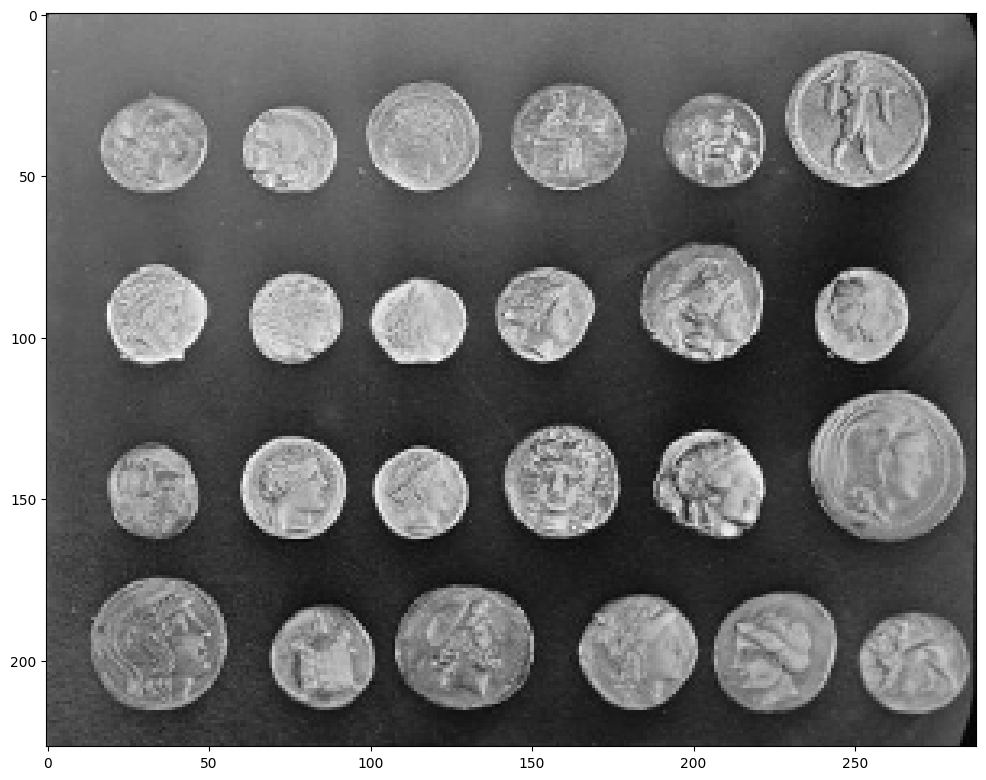

In [133]:
plt.imshow(img_scale, cmap='gray', vmin=0, vmax=1.0)
plt.show()

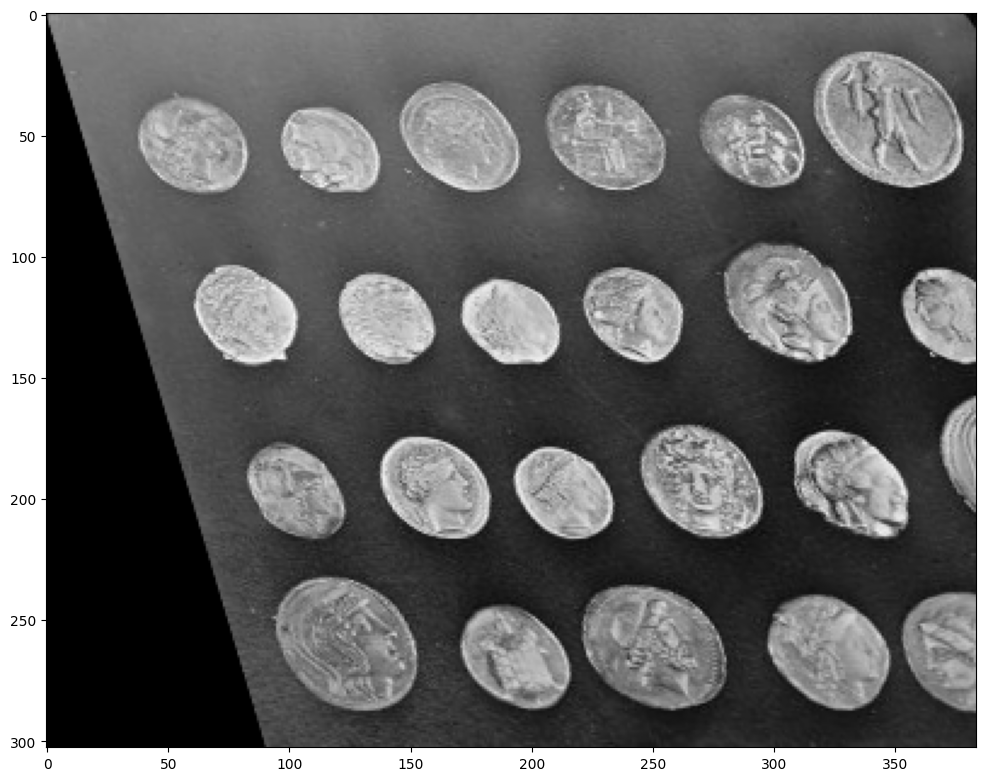

In [134]:
plt.imshow(img_affine, cmap='gray', vmin=0, vmax=1)
plt.show()